In [2]:

!pip install tensorflow==2.19.0 tensorflow-text==2.19.0 tf-keras==2.19.0 tensorflow-decision-forests==1.12.0

import os
import math
from pathlib import Path
import itertools
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
print("TensorFlow:", tf.__version__)

# Use mixed precision on GPU if available (speeds up + uses less memory on newer GPUs)
if tf.config.list_physical_devices('GPU'):
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision enabled.")
    except Exception as e:
        print("Mixed precision not enabled:", e)
else:
    print("No GPU detected — training will use CPU.")


TensorFlow: 2.19.0
Mixed precision enabled.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DATA_DIR_TRAIN = Path('/content/drive/MyDrive/data/Train')
DATA_DIR_TEST  = Path('/content/drive/MyDrive/data/Test')
# Check if directories exist
print("Train folder exists:", DATA_DIR_TRAIN.exists())
print("Test folder exists:", DATA_DIR_TEST.exists())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train folder exists: True
Test folder exists: True


In [4]:

# ====== CONFIG ======
#DATA_DIR_TRAIN = Path('./data/Train')  # e.g., ./data/Train/<class_name>/*
#DATA_DIR_TEST  = Path('./data/Test')   # e.g., ./data/Test/<class_name>/*

IMG_SIZE   = (224, 224)   # EfficientNetB0 default
BATCH_SIZE = 32
EPOCHS     = 30
VAL_SPLIT  = 0.15         # split from Train for validation
SEED       = 1337
AUTOTUNE   = tf.data.AUTOTUNE

MODEL_DIR  = Path('./models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / 'best_model.keras'
HISTORY_PLOT_PATH = MODEL_DIR / 'training_curves.png'

# Sanity checks
assert DATA_DIR_TRAIN.exists(), f"Training directory not found: {DATA_DIR_TRAIN.resolve()}"
assert DATA_DIR_TEST.exists(),  f"Test directory not found: {DATA_DIR_TEST.resolve()}"


Detected classes: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']
Found 1836 files belonging to 9 classes.
Using 1561 files for training.
Found 1836 files belonging to 9 classes.
Using 275 files for validation.
Found 109 files belonging to 9 classes.


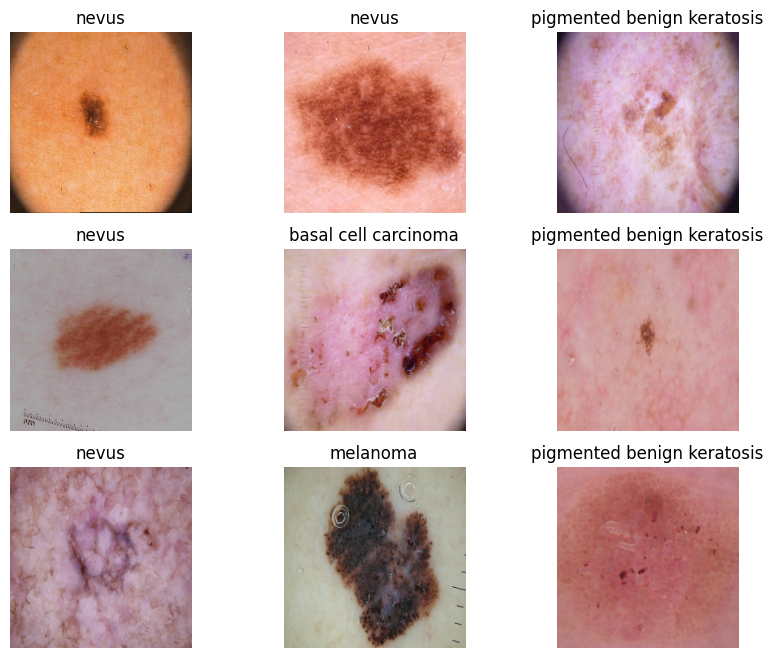

In [5]:

# List class names from Train directory
class_names = sorted([d.name for d in DATA_DIR_TRAIN.iterdir() if d.is_dir()])
num_classes = len(class_names)
print("Detected classes:", class_names)
assert num_classes >= 2, "Need at least two classes in ./data/Train"

# Create training & validation datasets from Train
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR_TRAIN,
    labels='inferred',
    label_mode='int',
    class_names=class_names,
    validation_split=VAL_SPLIT,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR_TRAIN,
    labels='inferred',
    label_mode='int',
    class_names=class_names,
    validation_split=VAL_SPLIT,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Test dataset from Test directory (no validation split here)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR_TEST,
    labels='inferred',
    label_mode='int',
    class_names=class_names,  # enforce same order
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False  # keep deterministic for evaluation
)

# Optimize pipelines
def configure(ds, shuffle=True):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = configure(train_ds, shuffle=True)
val_ds   = configure(val_ds,   shuffle=False)
test_ds  = configure(test_ds,  shuffle=False)

# Show a few samples
images, labels = next(iter(train_ds))
plt.figure(figsize=(10, 8))
for i in range(min(9, images.shape[0])):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")
plt.show()


In [6]:

# Data augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

# Base model: EfficientNetB0
base_model = EfficientNetB0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights='imagenet'
)
base_model.trainable = False  # start with frozen base

# Build the classifier head
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
# Use dtype float32 for final Dense when mixed precision is on
dtype = 'float32' if tf.keras.mixed_precision.global_policy().compute_dtype == 'float16' else None
outputs = layers.Dense(num_classes, activation='softmax', dtype=dtype)(x)
model = keras.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,100 (15.49 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.2965 - loss: 1.8632
Epoch 1: val_accuracy improved from -inf to 0.45455, saving model to models/best_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.2977 - loss: 1.8596 - val_accuracy: 0.4545 - val_loss: 1.4566 - learning_rate: 0.0010
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4870 - loss: 1.4015
Epoch 2: val_accuracy improved from 0.45455 to 0.53455, saving model to models/best_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.4871 - loss: 1.4013 - val_accuracy: 0.5345 - val_loss: 1.3230 - learning_rate: 0.0010
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5375 - loss: 1.3009
Epoch 3: val_accuracy did not improve from 0.53455
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 176ms/step - accuracy: 0.5376 - loss: 1.3006 - val_accuracy: 0.5345 - val_loss: 1.2271 - learning_rate: 0.0010
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5591 - loss: 1.

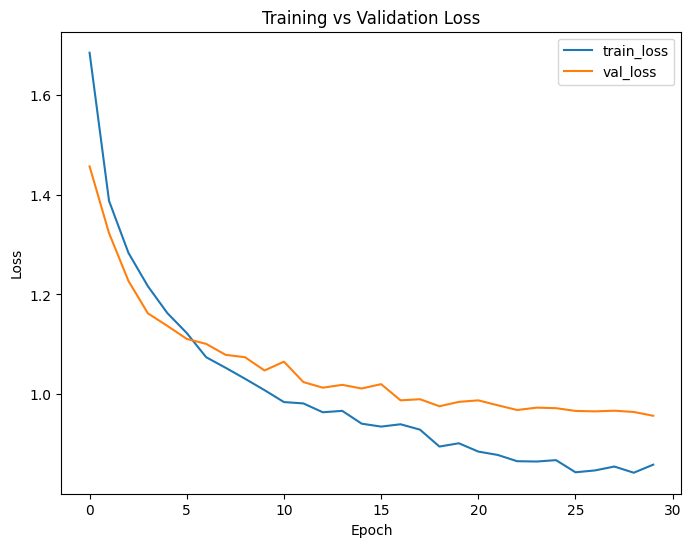

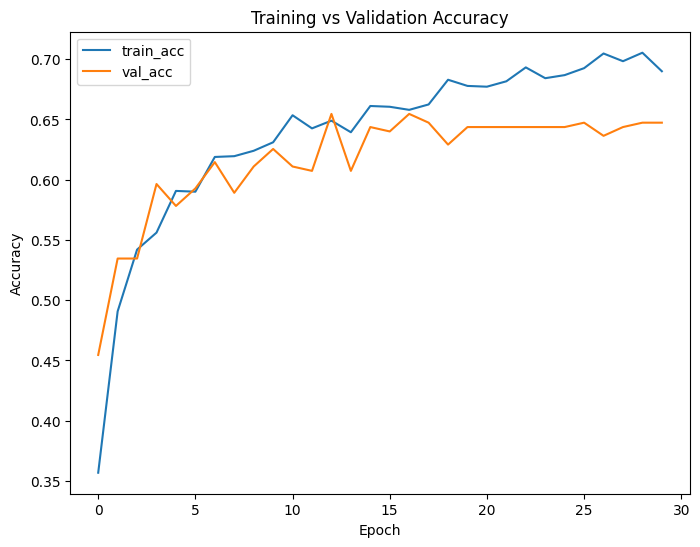

In [7]:

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
)
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Plot training curves
hist = history.history
plt.figure(figsize=(8,6))
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training vs Validation Loss'); plt.legend()
plt.savefig(HISTORY_PLOT_PATH.with_name('loss_curve.png')); plt.show()

plt.figure(figsize=(8,6))
plt.plot(hist['accuracy'], label='train_acc')
plt.plot(hist['val_accuracy'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training vs Validation Accuracy'); plt.legend()
plt.savefig(HISTORY_PLOT_PATH.with_name('accuracy_curve.png')); plt.show()


In [8]:

# Unfreeze last N layers for fine-tuning
N = 20  # you can increase if you have more data
for layer in base_model.layers[-N:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS//2,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Load best model (based on val_accuracy across both stages)
best_model = keras.models.load_model(BEST_MODEL_PATH)


Epoch 1/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.7011 - loss: 0.8258
Epoch 1: val_accuracy did not improve from 0.65455
49/49 ━━━━━━━━━━━━━━━━━━━━ 43s 275ms/step - accuracy: 0.7009 - loss: 0.8258 - val_accuracy: 0.6509 - val_loss: 0.9498 - learning_rate: 1.0000e-05
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6972 - loss: 0.8054
Epoch 2: val_accuracy did not improve from 0.65455
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 131ms/step - accuracy: 0.6973 - loss: 0.8056 - val_accuracy: 0.6436 - val_loss: 0.9512 - learning_rate: 1.0000e-05
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7016 - loss: 0.8087
Epoch 3: val_accuracy did not improve from 0.65455
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 127ms/step - accuracy: 0.7017 - loss: 0.8087 - val_accuracy: 0.6473 - val_loss: 0.9441 - learning_rate: 1.0000e-05
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6997 - loss: 0.8148
Epoch 4: val_accuracy did not improve from 0.65455
49/49 ━━━━━━━━━━━

Test accuracy: 0.4495, Test loss: 3.7919


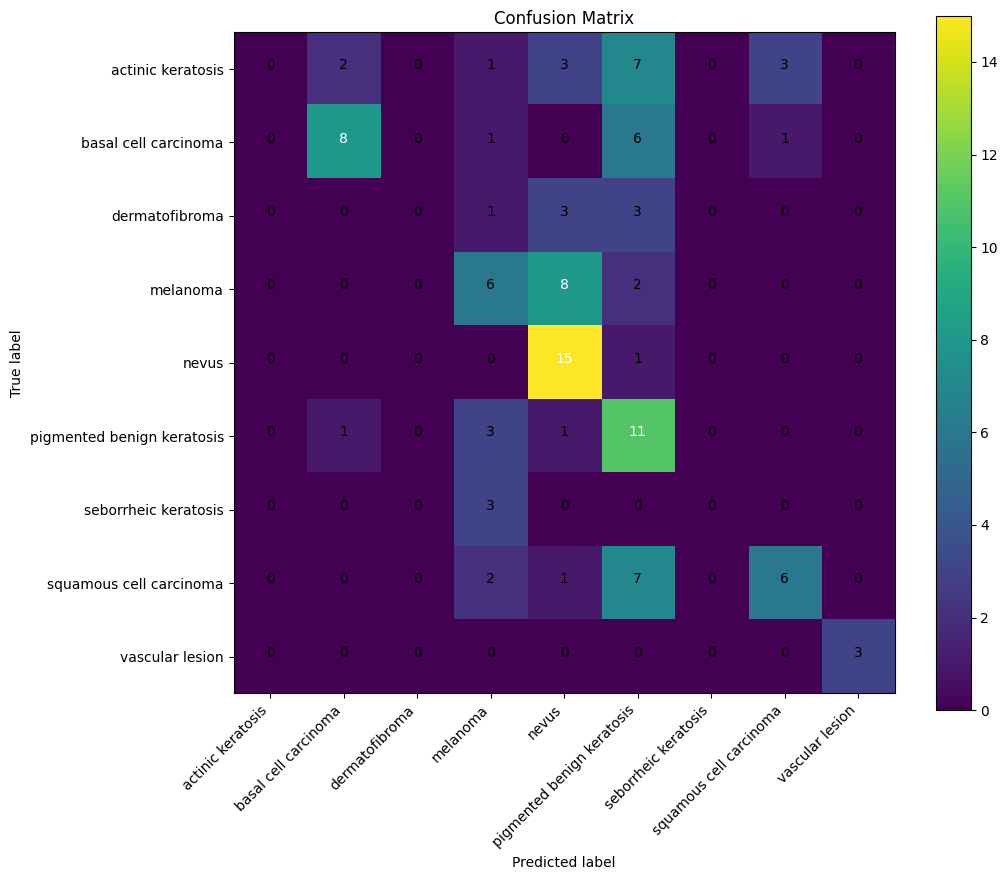

Classification Report:
                            precision    recall  f1-score   support

         actinic keratosis       0.00      0.00      0.00        16
      basal cell carcinoma       0.73      0.50      0.59        16
            dermatofibroma       0.00      0.00      0.00         7
                  melanoma       0.35      0.38      0.36        16
                     nevus       0.48      0.94      0.64        16
pigmented benign keratosis       0.30      0.69      0.42        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.60      0.38      0.46        16
           vascular lesion       1.00      1.00      1.00         3

                  accuracy                           0.45       109
                 macro avg       0.38      0.43      0.39       109
              weighted avg       0.39      0.45      0.39       109



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:

test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Predictions for confusion matrix and report
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy().tolist())
y_true = np.array(y_true)

y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
plt.figure(figsize=(1.2*num_classes, 1.0*num_classes))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


In [10]:

def predict_image(img_path):
    """Predicts class for a single image path."""
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    x = keras_image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    preds = best_model.predict(x, verbose=0)[0]
    idx = int(np.argmax(preds))
    return {
        'pred_class_index': idx,
        'pred_class_name': class_names[idx],
        'probs': {name: float(p) for name, p in zip(class_names, preds)}
    }

# Example (uncomment and set a path):
# result = predict_image('./data/Test/<class_name>/some_image.jpg')
# result


In [11]:

# Save label mapping
import json
label_map_path = MODEL_DIR / 'label_map.json'
with open(label_map_path, 'w') as f:
    json.dump({'class_names': class_names}, f, indent=2)
print(f"Saved label map to: {label_map_path.resolve()}")
print(f"Best model saved to: {BEST_MODEL_PATH.resolve()}")


Saved label map to: /content/models/label_map.json
Best model saved to: /content/models/best_model.keras
